## Evaluate saved posterior
Load a pre-trained posterior.pkl and run diagnostics without retraining.

In [1]:
import pickle
import numpy as np
import scipy as sps
import matplotlib.pyplot as plt

import torch
from torch.utils import data

import ili
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2026-04-08 15:24:56.288877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775676296.309215   28250 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775676296.315328   28250 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 15:24:56.336672: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Config — edit to match the run you want to evaluate

In [ ]:
# NPE architecture
#ARCH = 'nsf_h32_t3'
ARCH = 'nsf_h128_t5'

# Data
DATA_PATH = '/home/puehlengt/appletree/notebooks/harvested_testsims_3params.npy'
#NUM_SAMPLES = 2000
#NUM_SAMPLES = 10000
NUM_SAMPLES = 50000

# Histogram
N_BINS = 25
CS1_RANGE = [0, 150]
LOG_CS2_RANGE = [2.1, 4.1]

MODEL_DIR = f'3_param_trained_models/{NUM_SAMPLES}totalsamples_histogram_{N_BINS}bins_{ARCH}'

# Split (must match training)
SEED = 42
N_TEST = 10
VALIDATION_FRACTION = 0.1

# Set True for models trained with noise+z-norm preprocessing (new), False for old models
#USE_ZNORM = False
USE_ZNORM = True

## Load simulations

In [3]:
aa = np.load(DATA_PATH, allow_pickle=True).item()
param_bag = aa['param_bag']
events_bag = aa['events_bag']

In [4]:
apt_param_config = {
    'g1': {
        'prior_args': {'mean': 0.1367, 'std': 0.001},
        'init_mean': 0.1367, 'init_std': 0.001,
        'allowed_range': [0, 1.0],
        'unit': 'PE/photon',
    },
    'g2': {
        'prior_args': {'mean': 16.85, 'std': 0.46},
        'init_mean': 16.85, 'init_std': 0.46,
        'allowed_range': [0, 100.0],
        'unit': 'PE/electron',
    },
    'ambe_nr_rate': {
        'prior_args': {},
        'init_mean': 5500, 'init_std': 100,
        'allowed_range': [0, 10000000000.0],
        'unit': '1',
    },
}

## Reproduce train/val/test split

In [5]:
np.random.seed(SEED)
permuted_idx = np.random.permutation(NUM_SAMPLES)
idx_test = permuted_idx[:N_TEST]
idx_remaining = permuted_idx[N_TEST:]
n_train = int((1 - VALIDATION_FRACTION) * len(idx_remaining))
idx_train = idx_remaining[:n_train]
idx_val = idx_remaining[n_train:]
print(f'train: {len(idx_train)}, val: {len(idx_val)}, test: {len(idx_test)}')

train: 44991, val: 4999, test: 10


## Build histogram dataset

In [ ]:
cs1_edges = np.linspace(*CS1_RANGE, N_BINS + 1)
log_cs2_edges = np.linspace(*LOG_CS2_RANGE, N_BINS + 1)


def make_histogram(events, cs1_edges, log_cs2_edges):
    cs1 = events[0]
    log_cs2 = np.log10(events[1])
    n_events = len(cs1)
    h, _, _ = np.histogram2d(cs1, log_cs2, bins=[cs1_edges, log_cs2_edges])
    h = h / h.sum()
    last = n_events if USE_ZNORM else np.log10(n_events)
    return np.concatenate([h.flatten(), [last]]).astype(np.float32)


x_data = []
theta_data = []
for idx in range(NUM_SAMPLES):
    x_data.append(make_histogram(events_bag[idx], cs1_edges, log_cs2_edges))
    theta_data.append(np.array([v for v in param_bag[idx].values()], dtype=np.float32))

x_data = np.stack(x_data)
theta_data = torch.tensor(np.stack(theta_data))
print(f'x_data: {x_data.shape}, theta_data: {theta_data.shape}')

In [ ]:
if USE_ZNORM:
    with open(f'{MODEL_DIR}/x_norm_stats.pkl', 'rb') as f:
        norm_stats = pickle.load(f)
    x_mean = norm_stats['x_mean']
    x_std  = norm_stats['x_std']
    x_data = torch.tensor((x_data - x_mean) / x_std, dtype=torch.float32)
    print('Applied z-norm from training stats.')
else:
    x_mean, x_std = None, None
    x_data = torch.tensor(x_data, dtype=torch.float32)
    print('No z-norm (old model).')

## Load posterior

In [7]:
pkl_path = f'{MODEL_DIR}/posterior.pkl'
with open(pkl_path, 'rb') as f:
    posterior_ensemble = pickle.load(f)
print('Loaded:', pkl_path)

Loaded: 3_param_trained_models/50000totalsamples_histogram_25bins_nsf_h128_t5/posterior.pkl


## Single posterior — first test example

In [8]:
ind = 0
test_idx = idx_test[ind]
x_ = x_data[test_idx]
y_ = theta_data[test_idx].numpy()

torch.manual_seed(1234)
samples = posterior_ensemble.sample((1000,), x_)
log_prob = posterior_ensemble.log_prob(samples, x_)
samples = samples.cpu().numpy()
log_prob = log_prob.cpu().numpy()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 2148.48it/s]


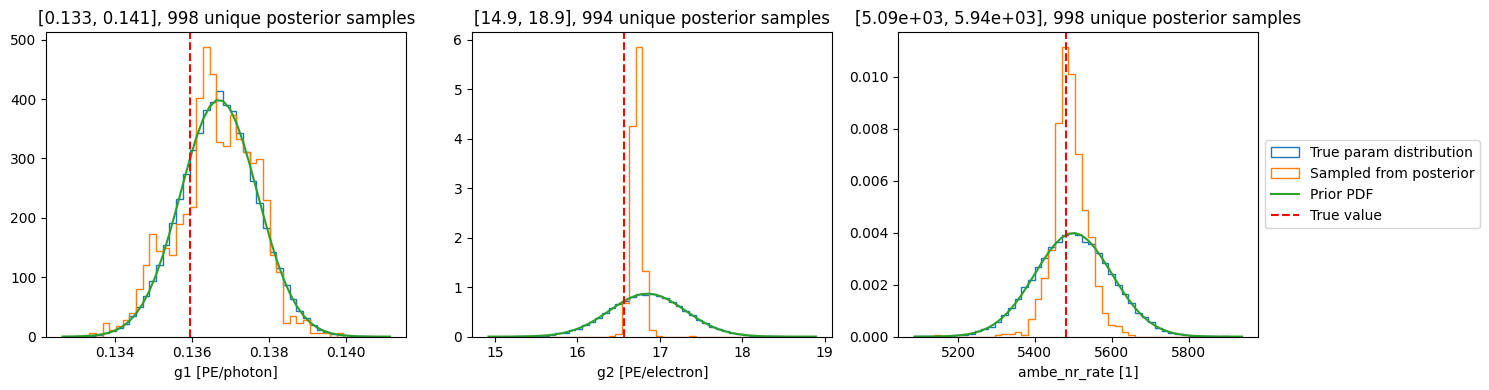

In [9]:
zzparams = theta_data.numpy()
param_names = list(apt_param_config.keys())

plt.figure(figsize=(15, 4))
for _ii, (key, val) in enumerate(apt_param_config.items()):
    zzz = zzparams[:, _ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    zzxx = np.linspace(zzmin, zzmax, 50)
    zzmean = val['prior_args'].get('mean', val['init_mean'])
    zzstd  = val['prior_args'].get('std',  val['init_std'])

    plt.subplot(131 + _ii)
    plt.hist(zzz, bins=zzxx, density=True, histtype='step', label='True param distribution')
    plt.hist(samples[:, _ii], bins=zzxx, density=True, histtype='step', label='Sampled from posterior')
    if zzstd > 0:
        plt.plot(zzxx, sps.stats.norm.pdf(zzxx, loc=zzmean, scale=zzstd), label='Prior PDF')
    plt.axvline(y_[_ii], color='red', linestyle='--', label='True value')
    plt.title(f'[{zzmin:.3g}, {zzmax:.3g}], {len(np.unique(samples[:, _ii]))} unique posterior samples')
    plt.xlabel(f'{key} [{val["unit"]}]')
    if _ii == 2:
        plt.legend(loc='center left', bbox_to_anchor=(1., 0.5))
plt.tight_layout()
plt.show()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 35816.61it/s]
INFO:root:Saving single posterior plot to 3_param_trained_models/50000totalsamples_histogram_25bins_nsf_h128_t5/plot_single_posterior.jpg...


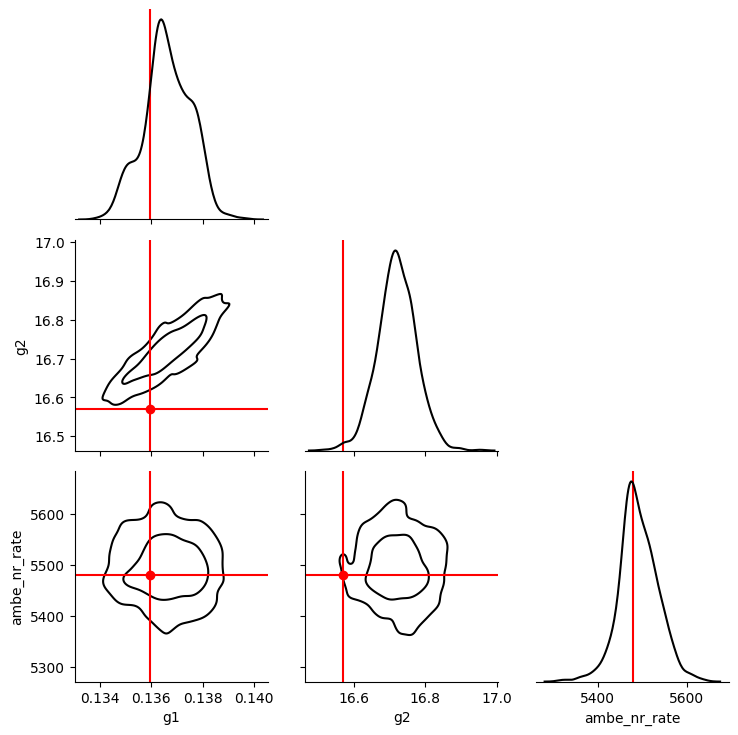

In [10]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names,
    out_dir=MODEL_DIR,
)
fig = metric(posterior=posterior_ensemble, x_obs=x_, theta_fid=y_)

## test2 — 2k fresh sims, indices NUM_SAMPLES onwards (never seen during training)

In [ ]:
N_TEST2 = 2000
idx_test2 = np.arange(NUM_SAMPLES, NUM_SAMPLES + N_TEST2)

x_test2 = []
theta_test2 = []
for idx in idx_test2:
    x_test2.append(make_histogram(events_bag[idx], cs1_edges, log_cs2_edges))
    theta_test2.append(np.array([v for v in param_bag[idx].values()], dtype=np.float32))

x_test2 = np.stack(x_test2)
if USE_ZNORM:
    x_test2 = torch.tensor((x_test2 - x_mean) / x_std, dtype=torch.float32)
else:
    x_test2 = torch.tensor(x_test2, dtype=torch.float32)
theta_test2 = np.stack(theta_test2)
print(f'x_test2: {x_test2.shape}, theta_test2: {theta_test2.shape}')

 19%|█▉        | 376/2000 [00:09<00:42, 38.45it/s]/home/puehlengt/ltu-ili/ili/utils/ndes_pt.py:206: UserWarning: Direct sampling took too long. The posterior is poorly constrained within the prior support. Consider using emcee sampling or using a larger prior support. Returning prior samples.
  warnings.warn(
100%|██████████| 2000/2000 [00:55<00:00, 36.18it/s]
INFO:root:Saving posterior samples to 3_param_trained_models/50000totalsamples_histogram_25bins_nsf_h128_t5/posterior_samples.npy...
INFO:root:Saving coverage plot to 3_param_trained_models/50000totalsamples_histogram_25bins_nsf_h128_t5/plot_coverage.jpg...
INFO:root:Saving ranks histogram to 3_param_trained_models/50000totalsamples_histogram_25bins_nsf_h128_t5/ranks_histogram.jpg...
100%|██████████| 100/100 [00:22<00:00,  4.42it/s]


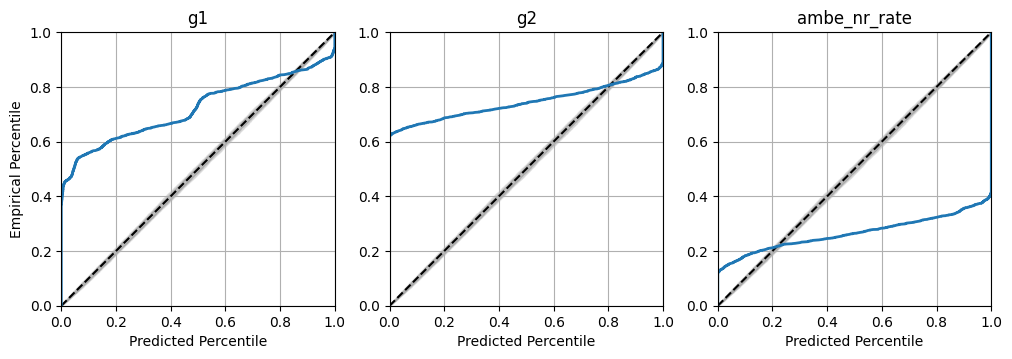

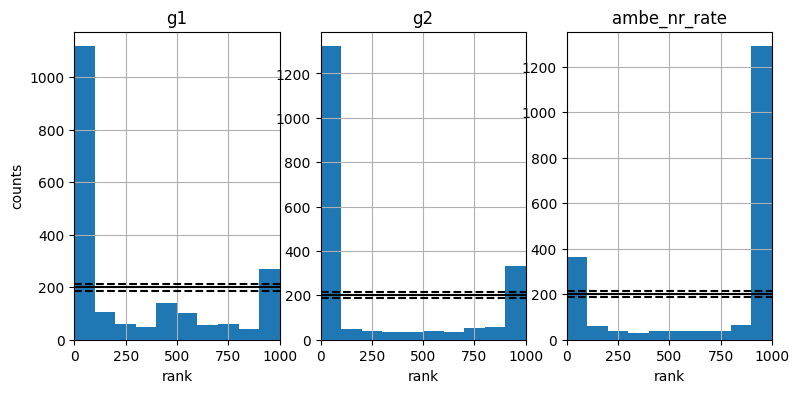

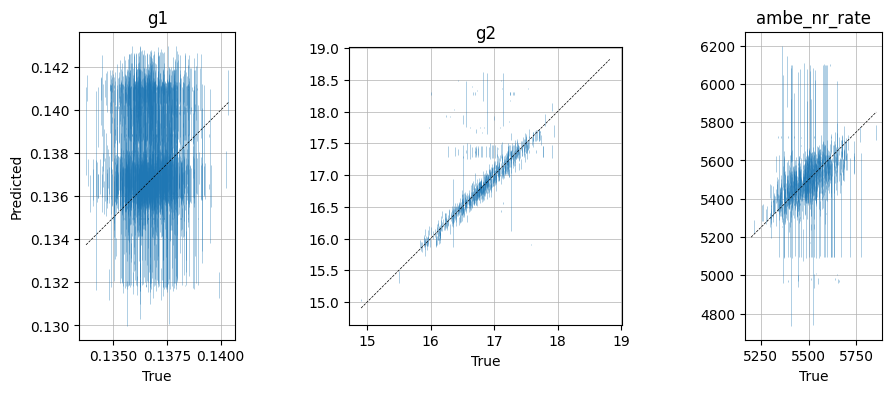

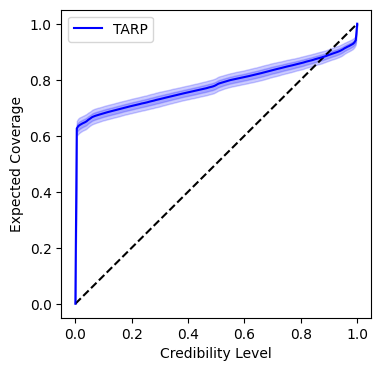

In [12]:
class HistDatasetX(data.Dataset):
    def __init__(self, x):
        self.x = x
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx]


metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=MODEL_DIR, labels=param_names,
    plot_list=['coverage', 'histogram', 'predictions', 'tarp'],
    save_samples=True,
)
fig = metric(
    posterior=posterior_ensemble,
    x=HistDatasetX(x_test2), theta=theta_test2,
)

In [13]:
MODEL_DIR

'3_param_trained_models/50000totalsamples_histogram_25bins_nsf_h128_t5'